# Fiji to Native Python Conversion
This notebook replaces the Fiji and TrackMate dependencies with native Python operations using `scikit-image`.

In [1]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Native image processing libraries
from cellpose import models, io
from skimage import io as skio
from skimage import measure, filters, color
io.logger_setup()

2026-03-22 17:28:32,498 [INFO] WRITING LOG OUTPUT TO C:\Users\ellag\.cellpose\run.log
2026-03-22 17:28:32,500 [INFO] 
cellpose version: 	4.0.9 
platform:       	win32 
python version: 	3.13.12 
torch version:  	2.10.0+cpu


(<Logger cellpose.io (INFO)>, WindowsPath('C:/Users/ellag/.cellpose/run.log'))

In [2]:
# Define your parent directory

# Creation of different directory for outputs
directory_path = Path("C:/Users/ellag/Meijer Lab/Imaging data/THP-1 cells/tif_files/ULK101/Round 1/1uM/")
filename = 'ULK101_1 uM_4.tif'

out = directory_path / "Output"
out.mkdir(exist_ok=True)

In [3]:
# Load the multi-Z, multi-channel TIFF using scikit-image
image_data = skio.imread(directory_path/filename)

# Print the shape so you can verify the dimension order. 
# We expect something like (Z, C, Y, X).
print(f"Original image shape: {image_data.shape}")

Original image shape: (22, 1024, 1024, 4)


Flattened image shape: (1024, 1024, 4) (Expected: X, Y, C)


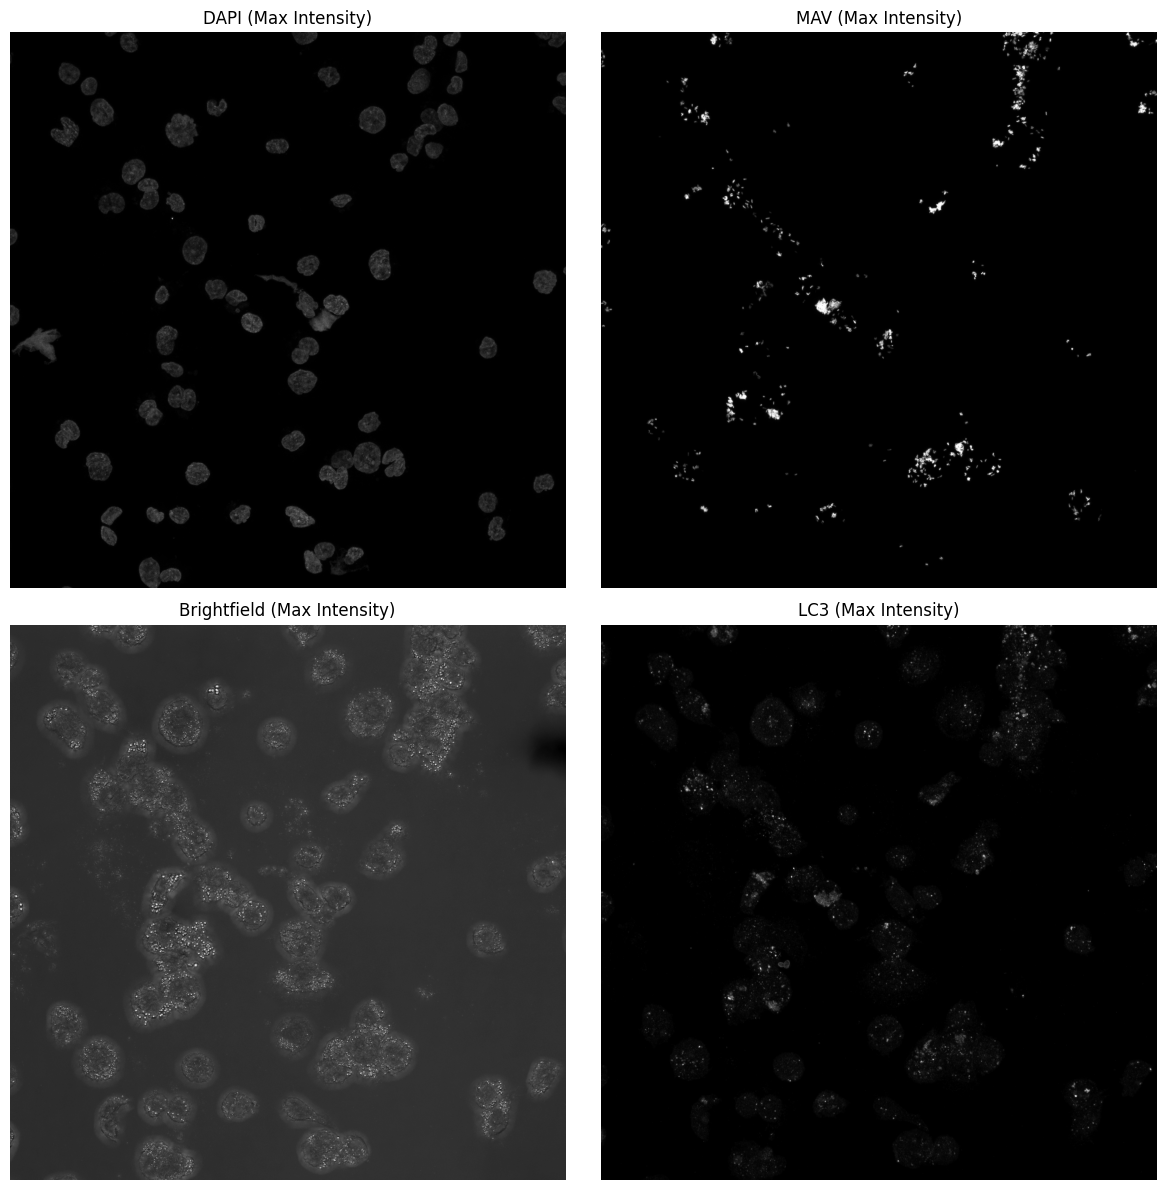

In [4]:
# Flatten the Z-stack using Maximum Intensity Projection (MIP)
# Projecting across the Z dimension (axis 0)
mip_image = np.max(image_data, axis=0) 

print(f"Flattened image shape: {mip_image.shape} (Expected: X, Y, C)")

# Extract the channels (C is the last dimension, so we slice the 3rd axis)
channel_dapi = mip_image[:, :, 0]
channel_lc3 = mip_image[:, :, 1]
channel_brightfield = mip_image[:, :, 2] 
channel_mav = mip_image[:, :, 3]

# Display the flattened channels in a 2x2 grid (No saving to disk)
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
ax = axes.ravel()

# DAPI
ax[0].imshow(channel_dapi, cmap='gray')
ax[0].set_title('DAPI (Max Intensity)')
ax[0].axis('off')

# MAV
ax[1].imshow(channel_mav, cmap='gray')
ax[1].set_title('MAV (Max Intensity)')
ax[1].axis('off')

# Brightfield
ax[2].imshow(channel_brightfield, cmap='gray')
ax[2].set_title('Brightfield (Max Intensity)')
ax[2].axis('off')

# LC3
ax[3].imshow(channel_lc3, cmap='gray')
ax[3].set_title('LC3 (Max Intensity)')
ax[3].axis('off')

plt.tight_layout()
plt.show()

In [8]:
channel_brightfield

array([[ 88,  88,  89, ...,  99, 109, 122],
       [ 88,  89,  89, ...,  93, 111, 124],
       [ 89,  88,  88, ...,  99, 106, 106],
       ...,
       [ 91,  91,  90, ...,  88,  88,  89],
       [ 92,  93,  93, ...,  87,  89,  90],
       [ 95,  96,  93, ...,  87,  89,  88]],
      shape=(1024, 1024), dtype=uint8)

In [ ]:
from skimage import exposure
from skimage.color import label2rgb
from skimage.transform import rescale, resize

# --- Settings ---
enhance_contrast = True
do_downsample = True
scale_factor = 0.25  # 0.5 means the image will be scaled to 50% of its original width and height

# 1. Start with the brightfield channel
bf_image_for_seg = channel_brightfield.copy()

# 2. Contrast Enhancement
if enhance_contrast:
    # CLAHE balances uneven lighting in brightfield images
    bf_image_for_seg = exposure.equalize_adapthist(bf_image_for_seg, clip_limit=0.03)

# 3. Downsampling
if do_downsample:
    # Rescale the image. anti_aliasing=True is recommended for continuous image data
    bf_image_for_seg = rescale(bf_image_for_seg, scale_factor, anti_aliasing=True)
    print(f"Downsampled image for Cellpose from {channel_brightfield.shape} to {bf_image_for_seg.shape}")

# 4. Cellpose Segmentation
model = models.CellposeModel(gpu=True)
masks, flows, styles = model.eval(bf_image_for_seg, diameter=None, resample=False)

# 5. Upsample masks back to original resolution (if downsampled)
if do_downsample:
    # CRITICAL: order=0 (nearest neighbor) and anti_aliasing=False ensures 
    # the integer mask IDs are preserved and not blurred into decimals.
    masks = resize(
        masks, 
        channel_brightfield.shape, 
        order=0, 
        preserve_range=True, 
        anti_aliasing=False
    ).astype(int)

# --- Display Results ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Display the original (or enhanced) brightfield image at full resolution
display_img = exposure.equalize_adapthist(channel_brightfield, clip_limit=0.03) if enhance_contrast else channel_brightfield

axes[0].imshow(display_img, cmap='gray')
axes[0].set_title(f"Brightfield (Contrast Enhanced: {enhance_contrast})")
axes[0].axis('off')

# Display the full-resolution masks overlaid on the full-resolution image
mask_overlay = label2rgb(masks, bg_label=0)
axes[1].imshow(display_img, cmap='gray')
axes[1].imshow(mask_overlay, alpha=0.4) 
axes[1].set_title(f"Cellpose Masks Overlay (Total cells: {masks.max()})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Downsampled image for Cellpose from (1024, 1024) to (256, 256)
2026-03-22 17:39:41,390 [INFO] Neither TORCH CUDA nor MPS version not installed/working.
2026-03-22 17:39:41,393 [INFO] >>>> using CPU
2026-03-22 17:39:41,395 [INFO] >>>> using CPU
2026-03-22 17:39:45,852 [INFO] >>>> loading model C:\Users\ellag\.cellpose\models\cpsam


In [13]:
masks[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint16)

AttributeError: 'list' object has no attribute 'max'

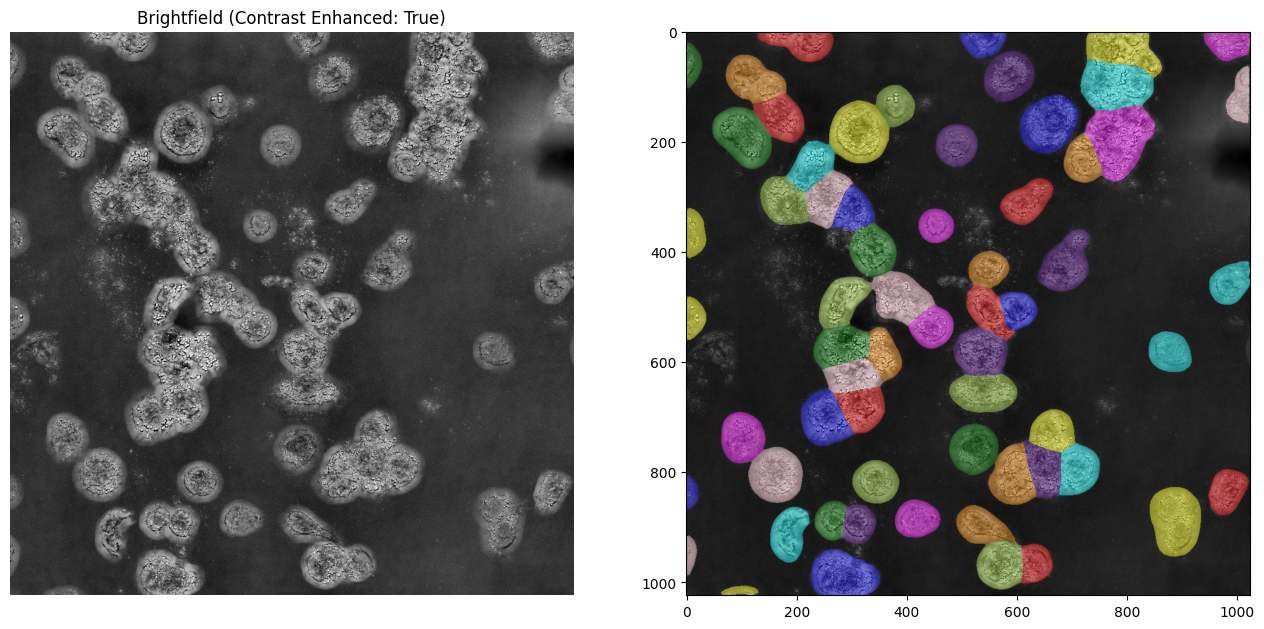

In [14]:
# --- 3. Display Results ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Display the image passed to Cellpose
axes[0].imshow(bf_image_for_seg, cmap='gray')
axes[0].set_title(f"Brightfield (Contrast Enhanced: {enhance_contrast})")
axes[0].axis('off')

# Display the masks overlaid on the image
# label2rgb randomly colors the integer labels. bg_label=0 makes the background transparent.
mask_overlay = label2rgb(masks[0], bg_label=0)
axes[1].imshow(bf_image_for_seg, cmap='gray')
axes[1].imshow(mask_overlay, alpha=0.4) # alpha controls the transparency of the masks
axes[1].set_title(f"Cellpose Masks Overlay (Total cells: {masks.max()})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
image_cp = f"{filename}/frame.tif"
model = models.CellposeModel(gpu=True, model_type='CP_20220523_104016')
imgs = io.imread(image_cp)

# Run cellpose
channels = [[0, 0]]
masks, flows, styles = model.eval(imgs, diameter=None, channels=channels)

# Save masks native outputs
io.save_to_png(imgs, masks, flows, image_cp)

# Label of the dead cells between the brackets
dead_cells = [1, 9]

# Clean the mask: Remove dead cells
cleaned_masks = masks.copy()
cleaned_masks[np.isin(cleaned_masks, dead_cells)] = 0

# Apply mask to bacterial channel to clear signal outside cells
bact_cleaned_signal = channel_bact * (cleaned_masks > 0)

In [ ]:
# 1. Threshold the cleaned bacterial signal
thresh = filters.threshold_otsu(bact_cleaned_signal)
binary_bact = bact_cleaned_signal > thresh

# 2. Label the detected bacterial particles
labeled_bact = measure.label(binary_bact)

# 3. Extract measurements (Centroid, Area)
properties = ['label', 'area', 'centroid']
bact_measurements = measure.regionprops_table(labeled_bact, properties=properties)

# Convert to pandas DataFrame and filter by size
df_spots = pd.DataFrame(bact_measurements)
df_spots = df_spots[df_spots['area'] >= 10]

# Rename columns to match expected output for spatial joining
df_spots.rename(columns={
    'centroid-0': 'POSITION_Y', 
    'centroid-1': 'POSITION_X',
    'label': 'ID'
}, inplace=True)

csvFileSpots = f"{out}bact_exportspots.csv"
df_spots.to_csv(csvFileSpots, index=False)

In [ ]:
# Visualize the bacterial detection overlay for Quality Control
fig, ax = plt.subplots(figsize=(10, 10))

# Display the raw or cleaned bacterial channel
ax.imshow(channel_bact, cmap='gray')

# Overlay the labeled regions with randomized colors
image_label_overlay = color.label2rgb(labeled_bact, image=channel_bact, bg_label=0)
ax.imshow(image_label_overlay, alpha=0.5)

ax.set_title('Bacterial Detections Overlay')
plt.axis('off')
plt.show()

In [ ]:
channels_of_interest = {'LC3': channel_lc3, 'LV': channel_lv}
final_results = df_spots[['ID']].copy()

for channel_name, channel_img in channels_of_interest.items():
    # Measure intensity of the current channel within the bacterial labels
    props = measure.regionprops_table(
        labeled_bact, 
        intensity_image=channel_img, 
        properties=['label', 'intensity_mean']
    )
    df_props = pd.DataFrame(props)
    
    # Rename column and merge
    df_props.rename(columns={'intensity_mean': f'Mean_{channel_name}', 'label': 'ID'}, inplace=True)
    final_results = final_results.merge(df_props, on='ID', how='left')

# Save final measurements
final_output_dir = f"{directory_path}/final_output/"
if not os.path.exists(final_output_dir):
    os.makedirs(final_output_dir)

output_path = Path(f"{final_output_dir}/{wanted_frame}_final_result.csv")
final_results.to_csv(output_path, index=False)

# Display the first few rows of the final dataset in Jupyter
display(final_results.head())